In [173]:
from Prepare_Data_Functions import normalize_df
from sklearn import preprocessing
from GA_functions import fitness, set_seed
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Load x_data

In [174]:
x = np.load('all_x.npy')

## Load y_data

In [175]:
y = np.load('all_spectra.npy')

## Load Target

In [176]:
df = normalize_df(pd.read_excel('Target.xlsx'))
target = df['B8'].values.reshape(-1,1)

## Find Best Match in Each Batch

In [185]:
batch_size = 15
n_iterations = 7
for iteration in range(1,n_iterations = 7):
    spectra = y[iteration*batch_size-batch_size:batch_size*iteration,:]
    conc = x[iteration*batch_size-batch_size:batch_size*iteration,:]
    desired_spectra = target
    set_seed(3)
    array, a, b = fitness(conc = conc, spectra = spectra, desired_spectra = desired_spectra)
    if iteration == 1:
        best_iteration = array[-1,:]
    else:
        best_iteration = np.vstack((best_iteration, array[-1,:]))

## Fitness Score every Iteration 

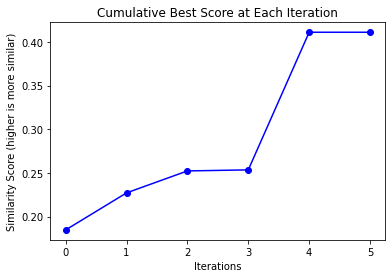

In [230]:
iteration = [0,1,2,3,4,5]
plt.plot(iteration, best_iteration[:,-1], '-ob')
plt.title('Cumulative Best Score at Each Iteration')
plt.xlabel('Iterations')
plt.ylabel('Similarity Score (higher is more similar)')
plt.savefig('score.jpg')

## Best Match every Iteration

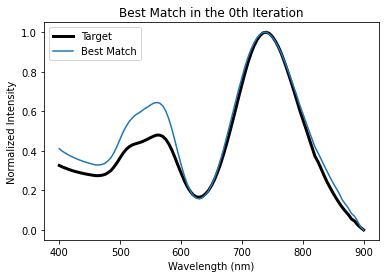

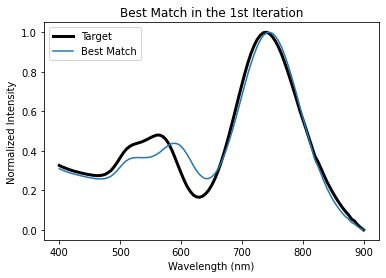

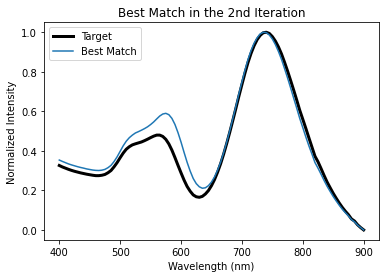

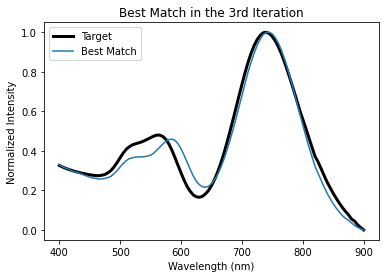

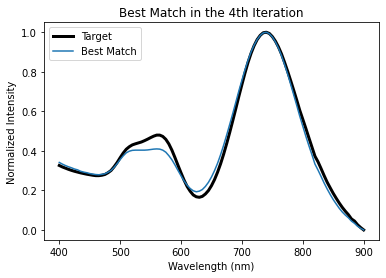

In [228]:
for i in range(5):
    fig, ax = plt.subplots()
    plt.plot(df['Wavelength'].values, desired_spectra, linewidth = 3, c = 'k', label = 'Target')
    plt.plot(df['Wavelength'].values, best_iteration[i,:][:-6], label = 'Best Match')
    if i == 1:
        plt.title('Best Match in the ' + str(i) +'st Iteration' )
    elif i == 2:
        plt.title('Best Match in the ' + str(i) +'nd Iteration' )
    elif i == 3:
        plt.title('Best Match in the ' + str(i) +'rd Iteration' )
    else:
        plt.title('Best Match in the ' + str(i) +'th Iteration' )
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Normalized Intensity')
    plt.legend()
    plt.savefig('Iteration_' + str(i) + '.jpg')
    

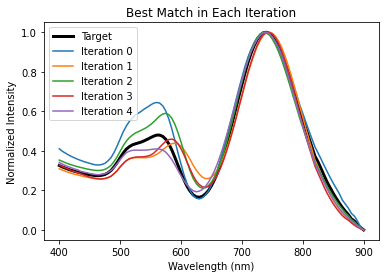

In [237]:
plt.plot(df['Wavelength'].values, desired_spectra, linewidth = 3, c = 'k', label = 'Target')
for i in range(5):
    plt.plot(df['Wavelength'].values, best_iteration[i,:][:-6], label = 'Iteration ' + str(i))
plt.title('Best Match in Each Iteration' )
plt.xlabel('Wavelength (nm)')
plt.ylabel('Normalized Intensity')
plt.legend()
#plt.savefig('Iteration_' + str(i) + '.jpg')
    

## All Spectra Generated

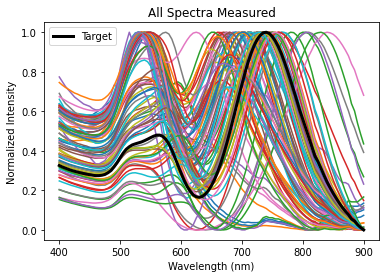

In [231]:
for i in range(0,y.shape[0],1):
    plt.plot(df['Wavelength'].values, y[i,:])
plt.plot(df['Wavelength'].values, desired_spectra, linewidth = 3, c = 'k', label = 'Target')
plt.legend()
plt.title('All Spectra Measured')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Normalized Intensity')
plt.savefig('all_spectra.jpg')